# What the enforced feature-norm bound costs on one-hot Criteo

Private SpiderBoost has no clipping line, so nothing at runtime makes its
sensitivity bound true. ADR-0009 left `L0` as an unchecked caller claim and
recorded the dilemma: a defensible constant on a heavy-tailed feature set is
*either* fitted on the data — an access no budget accounts for — *or* large
enough to drown the signal.

ADR-0012 closed the first horn. `L0` is no longer estimated: a per-record map
rescales every row to `l2` norm at most `R`, reading no aggregate and costing
no budget, and `accounting.lipschitz` turns `R` and a bias flag into
`(L0, L1, eta)` with no data argument at all. Nothing here reopens that. This
notebook measures the **second** horn, which ADR-0012 did not close and
changed the shape of: `R` is now free, so the question is no longer whether the
data forces `L0` up, but whether any `R` leaves Criteo's signal standing once
the noise that `R` implies is added.

Two costs move in opposite directions, and both are visible below.

- **`R` too large.** Above the data's own norms the cap binds on nothing, so
  the features are unchanged while `L0 = sqrt(R^2 + 1)` grows and Theorem
  B.3's step size `eta = 1/(2 L1) = 2/L0^2` shrinks. One step moves the
  parameters by `eta * ||g||` and is displaced by `eta * mu * L0 / b` per
  coordinate, so signal falls like `1/R^2` and noise only like `1/R`.
- **`R` too small.** The cap saturates every row, the feature block has norm
  exactly `R`, and the gradient signal in it scales like `R` — but the
  augmented norm is `sqrt(R^2 + 1)`, floored at 1 by the bias coordinate. Below
  `R = 1` the noise stops falling and the signal does not.

So there should be an interior optimum, sitting where `R` meets this dataset's
norm scale. That is a fact about Criteo rather than about the algorithm, which
is why it is measured here and not read out of a paper.

**The encoding is one-hot, and that is what changed.** An earlier execution of
this notebook ran the same grid on `load_criteo(features="all")`, where the 26
categorical columns are each collapsed to one frequency float. This one runs
`load_criteo_one_hot` (ADR-0020): 551,947 coordinates, of which a row occupies
39. Three things about that move matter to this notebook specifically, and each
gets a section below.

1. **The norm scale the optimum sits against is different, and it is public.**
   A one-hot row carries 26 ones and 13 integer values in `[0, log 2]`, so its
   augmented norm is at most `sqrt(26 + 13 (log 2)^2 + 1) ≈ 5.77` — for every
   record in the file, derivable from the schema without reading a row.
2. **`d` is 551,947 rather than 39.** SpiderBoost perturbs every coordinate, so
   at a fixed per-coordinate scale the displacement vector is 119 times longer.
   Section 2 puts that arithmetic beside `R`'s.
3. **There is no standardized chain to compare against.** ADR-0020 declines the
   `standardize` axis, because centring a one-hot column fills it, so the
   second grid the frequency-encoded execution ran — ADR-0013's price, paid —
   has no counterpart here. This notebook is one grid, not two.

**What this notebook may not do, and does not.** ADR-0012 forbids choosing `R`
by reading the data's norm distribution: an `R` arrived at that way is a fitted
`L0`, no more honest for being generous. The grid below is fixed before
anything loads — a log grid from 0.25 to 16, unchanged from the
frequency-encoded execution — and nothing here computes a norm, a maximum or a
quantile of the features. The 5.77 above is not an exception: it is a
consequence of the encoding's shape, which is public, and it would be the same
number on a file of different rows.

That distinction does not make the output free to use. Any `R` carried out of
here into a reported epsilon inherits ADR-0012's provenance obligation: this
is a non-private exploratory run, its own epsilon is invalid, and that has to
be said beside the number rather than left to be inferred.

In [1]:
import os

# JAX reads this once, at import, and takes 75% of the device without it.
# This card is shared, and the fraction is of the whole device rather than of
# what is free, so a notebook that assumes an empty one fails here rather than
# at its first large allocation. One SpiderBoost step at b1 = 8192 over
# 551,947 coordinates peaks near 19 GB, which is what this has to hold.
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.62")

import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from dimma.accounting.lipschitz import logreg_bce_constants
from dimma.accounting.spiderboost import epsilon as spiderboost_epsilon
from dimma.accounting.spiderboost import noise_scales
from dimma.algorithms.sgd import train as sgd
from dimma.algorithms.spiderboost import train as spiderboost
from dimma.core import updates
from dimma.datasets.criteo import load_criteo_one_hot
from dimma.metrics.decomposition import log_loss_decomposition
from dimma.metrics.operating_point import confusion_at
from dimma.metrics.ranking import pr_curve
from dimma.metrics.scoring import log_loss, normalized_entropy
from dimma.models.logreg import forward_sparse, init_params

DEVICE = "gpu" if any(d.platform == "gpu" for d in jax.devices()) else "cpu"
print(f"jax devices: {jax.devices()}  ->  DEVICE = {DEVICE!r}")

# Figure palette. Blue carries the private arm, orange the same run with the
# noise switched off; the two reference levels are drawn in grey because they
# are the frame rather than a third and fourth series.
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"
PRIVATE_C, CONTROL_C = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "lines.linewidth": 2.0, "lines.markersize": 6.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "font.size": 10,
})

jax devices: [CudaDevice(id=0)]  ->  DEVICE = 'gpu'


## 1. The protocol, fixed before anything ran

Every row of every table below is the same run with one thing changed. The
budget, the step count, the schedule and the two batch sizes are held; `R`
moves, and with it the three quantities `R` implies.

`R` is the only axis because it is the only one under test. A learning-rate
sweep would be meaningless here: Theorem B.3 *fixes* `eta = 1/(2 L1)`, so the
step size is not a hyperparameter of this algorithm — it is a consequence of
`R`, and departing from it drops the convergence guarantee while leaving the
privacy intact.

In [2]:
SMOKE = False            # flip to True for a minutes-long shape check

TARGET_EPSILON = 3.0
TARGET_DELTA = 1e-6
STEPS = 10_000

# Algorithm 2's schedule. One anchor release every 50 steps, so 200 of them
# and 9,800 variation releases, composed as two subsampled Gaussians.
ANCHOR_INTERVAL = 50
B1 = 8192      # anchor branch, Algorithm 2's b_1
B2 = 1024      # variation branch, b_2

# Fixed a priori, and unchanged from the frequency-encoded execution so that
# the two grids are read against each other. A log grid straddling 1, which is
# where the bias coordinate's contribution to the augmented norm puts a floor,
# carried up to 16 so that it also straddles this encoding's own ceiling of
# about 5.77. Nothing here reads the data to pick it.
R_GRID = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

# `dimma.models.logreg` carries a bias, which augments the feature vector
# with a constant 1. Worth a factor of two in L1 at R = 1, and a wrong one
# reports an epsilon that is simply false — ADR-0012.
HAS_BIAS = True
N_BINS = 15
INIT_SEED = 0
BASE_SEED = 20260823

if SMOKE:
    STEPS = 200
    R_GRID = [1.0, 16.0]
    print("SMOKE: a shape check, not the run this file carries\n")

print(f"epsilon = {TARGET_EPSILON} at delta = {TARGET_DELTA}, "
      f"{STEPS:,} steps, anchor every {ANCHOR_INTERVAL}")
print(f"R grid: {R_GRID}")

epsilon = 3.0 at delta = 1e-06, 10,000 steps, anchor every 50
R grid: [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]


## 2. Where `R` enters, before any data is loaded

`logreg_bce_constants` takes `R` and a bias flag and returns the triple
together, because Theorem B.3 welds them: `L0 = sqrt(R^2 + 1)`,
`L1 = L0^2 / 4`, `eta = 1/(2 L1)`. This cell touches no array. It is the whole
of what `R` does to the guarantee, and it is why the same `R` cannot be argued
about twice.

Read the fifth column against the second. Across the grid `L0` grows by a
factor of about 15 and the noise per released coordinate grows with it,
linearly; the step size falls by a factor of about 242, quadratically, because
`eta = 2/L0^2`. That asymmetry is the "`R` too large" arm of the trade, and it
is arithmetic rather than measurement — it is true before any data is seen.
What measurement has to settle is where it starts binding, which is the other
arm's business.

**The last column is what the encoding changed.** Per released *coordinate* the
noise is what it was; the displacement of the parameter vector is that times
`sqrt(d)`, and `d` is 551,947 rather than 39. Nothing about the guarantee moves
— the accountant is not told the dimension — but the distance a step is pushed
off course grows by a factor of 119, and it is the reason to expect this grid
to look worse than the frequency-encoded one at every `R`.

In [3]:
ONE_HOT_WIDTH = 551_947    # printed from the split below; stated here so the
                           # table can be read before the data is loaded

print(f"{'R':>6} {'L0':>8} {'L1':>9} {'eta':>10} {'noise/coord':>12} "
      f"{'x sqrt(d)':>11}")
for bound in R_GRID:
    constants = logreg_bce_constants(bound, has_bias=HAS_BIAS)
    # The anchor branch's standard deviation per released coordinate, at a
    # unit multiplier: what a step's noise is proportional to.
    per_coordinate = constants.lipschitz_constant / B1
    print(f"{bound:>6} {constants.lipschitz_constant:8.4f} "
          f"{constants.smoothness_constant:9.4f} {constants.step_size:10.4f} "
          f"{per_coordinate:12.3e} "
          f"{per_coordinate * np.sqrt(ONE_HOT_WIDTH):11.3e}")

     R       L0        L1        eta  noise/coord   x sqrt(d)
  0.25   1.0308    0.2656     1.8824    1.258e-04   9.348e-02
   0.5   1.1180    0.3125     1.6000    1.365e-04   1.014e-01
   1.0   1.4142    0.5000     1.0000    1.726e-04   1.283e-01
   2.0   2.2361    1.2500     0.4000    2.730e-04   2.028e-01
   4.0   4.1231    4.2500     0.1176    5.033e-04   3.739e-01
   8.0   8.0623   16.2500     0.0308    9.842e-04   7.312e-01
  16.0  16.0312   64.2500     0.0078    1.957e-03   1.454e+00


## 3. What one run is scored on

Threshold-free scores first, from `dimma.metrics`: log loss is the objective
the loop descends, and normalized entropy states the constant predictor as
1.0. Beside them the **log-loss decomposition**, which is what this notebook
actually turns on.

*Drowning the signal* is a claim about **resolution** — how far the bins pull
apart from the base rate — and not about calibration. Under equal-mass binning
resolution is exactly the part a ranking score can see, and calibration
carries everything a ranking score is invariant to, so the two terms land on
"what PR-AUC measures" and "what PR-AUC cannot". A private arm that loses
resolution has lost the signal; one that only gains calibration has kept it
and is stating it wrongly, which is a different failure with a different fix.

PR-AUC is reported alongside because it is the CTR-benchmark convention and
because it is the number a reader of #11 will look for. It is not the number
selection is done on. ROC-AUC appears nowhere: at a 25% base rate it is
flattering and reads well for a model that has learned nothing.

**The operating point.** A confusion matrix needs one and `p > 0.5` is the
wrong one — at this base rate a calibrated model rarely emits it at all, so
that threshold reports the base rate rather than the classifier. The threshold
is the **training-split base rate**, fixed before any run, identical for every
row, and a training-split statistic, so it falls under the caveat ADR-0008
already records rather than adding a read of the test labels.

The PR curve and the confusion matrix come from `dimma.metrics.ranking` and
`dimma.metrics.operating_point`. The frequency-encoded execution carried a
local copy of each, written when the library had neither; both are gone.

In [4]:
_score = jax.jit(jax.vmap(forward_sparse, in_axes=(None, 0, 0)))

# 39 stored entries a row, whatever the record holds: a property of the
# encoding rather than of the data, which is ADR-0020's whole point. Every
# split loaded below is asserted against it.
STORED_PER_ROW = 39


def per_sample_sparse_bce(params, packed, y):
    """BCE for one example held as concatenated indices and values."""
    idx = packed[:STORED_PER_ROW].astype(jnp.int32)
    val = packed[STORED_PER_ROW:]
    logit = forward_sparse(params, idx, val)
    return jax.nn.softplus(logit) - logit * y


def pack(split):
    """The training rows as one array: 39 indices, then 39 values.

    A dimma per-sample loss takes one `x` and a training loop slices it
    along one leading axis, so the pair a sparse row arrives in has to
    travel as one. The bias-reduced-SGD sweep's cell, and the DP-SGD
    sweep's.
    """
    return jnp.concatenate(
        [split.idx_train.astype(jnp.float32), split.val_train], axis=1
    )


def evaluate(probs, labels, threshold):
    """Every number one arm is read on, from one array of probabilities."""
    confusion = confusion_at(probs, labels, threshold)
    parts = log_loss_decomposition(probs, labels, n_bins=N_BINS)
    flagged = confusion.true_positives + confusion.false_positives
    clicks = confusion.true_positives + confusion.false_negatives
    return dict(
        loss=log_loss(probs, labels),
        ne=normalized_entropy(probs, labels),
        pr_auc=pr_curve(probs, labels).average_precision,
        resolution=float(parts.resolution),
        calibration=float(parts.calibration),
        precision=(confusion.true_positives / flagged if flagged
                   else float("nan")),
        recall=(confusion.true_positives / clicks if clicks else float("nan")),
        confusion=confusion,
    )


def probabilities(params, split):
    """`forward_sparse` is a single-example function; squash once here."""
    logits = _score(params, split.idx_test, split.val_test)
    return np.asarray(jax.nn.sigmoid(logits), dtype=np.float64)


COLUMNS = (f"{'log-loss':>9} {'NE':>7} {'PR-AUC':>7} {'resol':>7} "
           f"{'calib':>7} {'prec':>6} {'recall':>7}")


def row(label, result, width=22):
    """One row of the grid table, so every table below shares a shape."""
    return (f"{label:<{width}}{result['loss']:9.4f} {result['ne']:7.4f} "
            f"{result['pr_auc']:7.4f} {result['resolution']:7.4f} "
            f"{result['calibration']:7.4f} {result['precision']:6.3f} "
            f"{result['recall']:7.3f}")


def show_confusion(confusion, title):
    """The 2x2 as a table -- four numbers do not need a chart."""
    print(f"{title}\n{'':>12}{'pred 0':>10}{'pred 1':>10}")
    print(f"{'true 0':>12}{confusion.true_negatives:>10,}"
          f"{confusion.false_positives:>10,}")
    print(f"{'true 1':>12}{confusion.false_negatives:>10,}"
          f"{confusion.true_positives:>10,}")

## 4. One `R`, both arms

`fit` runs Algorithm 2 at the constants `R` implies. The **control** is the
identical run with the three noise scales at `1e-12` — same `R`, same capped
data, same step size, same sampling. That is what separates the two costs:
the gap from the control to the uncapped ceiling is what the **cap** took, and
the gap from the private arm to the control is what the **noise** took.

The control is not a baseline in ADR-0005's sense. It is the same loop with
one term switched off, and it spends no meaningful epsilon; the real baseline
is plain SGD, which appears once at the end as the ceiling.

Algorithm 2 has no clipping line, so nothing here allocates a per-example
gradient block: `gradients.batch_grads` differentiates the mean and one
gradient comes back for the whole batch. That is why a 551,947-coordinate run
fits on this device at `b1 = 8192` when DP-SGD's per-example path needs 2.7 GB
at a lot of 1,024 (ADR-0020's closing consequence). What this loop does
allocate per step is a handful of vectors of width `d`, and the wall clock
below is mostly the cost of drawing and adding them.

In [5]:
def sweep_one(bound, split, y_test, threshold, start):
    """Both arms at one `R`, plus the scales and the epsilon they cost."""
    n_train = split.idx_train.shape[0]
    packed = pack(split)
    constants = logreg_bce_constants(bound, has_bias=HAS_BIAS)
    scales = noise_scales(
        lipschitz_constant=constants.lipschitz_constant,
        smoothness_constant=constants.smoothness_constant,
        target_epsilon=TARGET_EPSILON, target_delta=TARGET_DELTA,
        steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
        anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
        dataset_size=n_train,
    )
    spent = spiderboost_epsilon(
        lipschitz_constant=constants.lipschitz_constant,
        smoothness_constant=constants.smoothness_constant,
        **scales._asdict(), target_delta=TARGET_DELTA, steps=STEPS,
        anchor_interval=ANCHOR_INTERVAL, anchor_expected_batch_size=B1,
        variation_expected_batch_size=B2, dataset_size=n_train,
    )
    assert spent <= TARGET_EPSILON + 1e-9

    def fit(three, index):
        output, _ = spiderboost.train(
            per_sample_sparse_bce, start, updates.sgd(constants.step_size),
            packed, split.y_train,
            jax.random.key(BASE_SEED + index),
            np.random.default_rng([BASE_SEED, index]),
            steps=STEPS, anchor_interval=ANCHOR_INTERVAL,
            anchor_expected_batch_size=B1, variation_expected_batch_size=B2,
            **three,
        )
        return evaluate(probabilities(output, split), y_test, threshold)

    off = dict.fromkeys(scales._asdict(), 1e-12)
    return dict(R=bound, constants=constants, epsilon=spent,
                private=fit(scales._asdict(), 0), control=fit(off, 1))

## 5. The grid

All 39 features one-hot, the full file, the split seed fixed at 0. Each `R`
reloads, because the cap goes last in the loader's chain and after every fitted
map — applying it any earlier would bound nothing afterwards.

There is one chain and not two. `load_criteo_one_hot` offers no `standardize`
axis at all (ADR-0020): centring a one-hot column gives every row a non-zero
entry in it, which is the dense matrix the loader exists to avoid. So ADR-0013's
price — the one the frequency-encoded execution paid in a second grid — is not
available to pay here, and the closing says what that costs the comparison.

In [6]:
def run_grid():
    """The whole grid on the one chain, plus the floor and the ceiling."""
    results, t0 = [], time.time()
    for bound in R_GRID:
        split = load_criteo_one_hot(preprocess=True, download=False, seed=0,
                                    device=DEVICE, feature_norm_bound=bound)
        assert split.idx_train.shape[1] == STORED_PER_ROW
        y_test = np.asarray(split.y_test, dtype=np.float64)
        threshold = float(split.y_train.mean())
        start = init_params(jax.random.key(INIT_SEED), split.num_features)
        results.append(sweep_one(bound, split, y_test, threshold, start))
        print(f"  R = {bound} done  ({time.time() - t0:.0f}s)")

    # The two reference levels, on the same chain with no cap and so no
    # constants implied and no epsilon claimed.
    split = load_criteo_one_hot(preprocess=True, download=False, seed=0,
                                device=DEVICE, feature_norm_bound=None)
    assert split.idx_train.shape[1] == STORED_PER_ROW
    y_test = np.asarray(split.y_test, dtype=np.float64)
    threshold = float(split.y_train.mean())
    start = init_params(jax.random.key(INIT_SEED), split.num_features)

    trained = sgd.train(
        per_sample_sparse_bce, start, updates.sgd(0.3),
        pack(split), split.y_train,
        np.random.default_rng([BASE_SEED, 999]),
        steps=STEPS, batch_size=1024,
    )
    ceiling = evaluate(probabilities(trained, split), y_test, threshold)

    constant = evaluate(np.full_like(y_test, threshold), y_test, threshold)
    # Its PR-AUC is entered as the base rate rather than computed: every
    # score is identical, so an average precision over them would be
    # reporting the order the rows arrived in. Its resolution the
    # decomposition already returns as exactly zero.
    constant["pr_auc"] = float(y_test.mean())
    print(f"total {time.time() - t0:.0f}s on {DEVICE}")
    return results, ceiling, constant, threshold, split


grid, ceiling, constant, threshold, last_split = run_grid()
print(f"\n{last_split.num_features:,} feature coordinates, "
      f"{last_split.idx_train.shape[1]} stored a row")

criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point. Every row then rescaled to l2 norm at most 0.25, one record at a time.


W0823 21:23:33.605910 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


W0823 21:23:35.802022 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


W0823 21:26:02.414723 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


W0823 21:26:04.576443 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


...

W0823 21:55:53.682591 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


W0823 21:55:55.871006 2203108 hlo_rematerialization.cc:3282] Can't reduce memory use below 27.89GiB (29951605918 bytes) by rematerialization; only reduced to 35.93GiB (38583338092 bytes), down from 35.93GiB (38583338100 bytes) originally


  R = 16.0 done  (2092s)


criteo: 39 features as index/value pairs. I1-I13 at indices 0-12: NaN filled with the train-split median, clipped below at 0, then log1p — the fill and the clip are no-ops on stored values that carry neither NaN nor negatives, and log1p acts on [0, 1]. C1-C26 one-hot at their native train-split cardinalities, each column holding its own block of the index space and one slot reserved for IDs unseen in the training split, so every row carries exactly 39 entries whatever it holds. Not standardized: centring a one-hot column fills it, and the sparsity is the point.


total 2108s on gpu

551,947 feature coordinates, 39 stored a row


In [7]:
print(f"decision threshold p >= {threshold:.4f} "
      f"(the training-split base rate)\n")
print(f"{'':<22}{COLUMNS}")
print(row("constant predictor", constant))
for result in grid:
    print(row(f"R = {result['R']}, eps = {result['epsilon']:.2f}",
              result["private"]))
    print(row("    same R, no noise", result["control"]))
print(row("uncapped plain SGD", ceiling))

decision threshold p >= 0.2510 (the training-split base rate)

                       log-loss      NE  PR-AUC   resol   calib   prec  recall
constant predictor       0.5645  1.0000  0.2520  0.0000  0.0000  0.252   1.000
R = 0.25, eps = 3.00     0.5211  0.9232  0.4424  0.0492  0.0065  0.369   0.679
    same R, no noise     0.5185  0.9185  0.4503  0.0519  0.0066  0.378   0.666
R = 0.5, eps = 3.00      0.5037  0.8923  0.4739  0.0618  0.0020  0.393   0.683
    same R, no noise     0.5012  0.8878  0.4808  0.0645  0.0022  0.402   0.671
R = 1.0, eps = 3.00      0.4956  0.8780  0.4888  0.0682  0.0005  0.406   0.684
    same R, no noise     0.4927  0.8728  0.4971  0.0717  0.0009  0.415   0.674
R = 2.0, eps = 3.00      0.4927  0.8729  0.4949  0.0709  0.0002  0.410   0.684
    same R, no noise     0.4891  0.8664  0.5049  0.0749  0.0007  0.420   0.678
R = 4.0, eps = 3.00      0.4919  0.8714  0.4967  0.0716  0.0002  0.411   0.685
    same R, no noise     0.4879  0.8643  0.5075  0.0761  0.0006  0.4

### Reading the grid

**The curve has an interior optimum, and it is at `R = 4.0`.** Resolution
climbs `0.0492 → 0.0618 → 0.0682 → 0.0709 → 0.0716` as `R` goes from 0.25 to 4,
then falls to `0.0669` at 8 and `0.0550` at 16. Both ends are cliffs and the top
is flat: `R = 1`, `2` and `4` span `0.0034` of resolution between them, against
`0.0224` from the peak down to `R = 0.25`.

**`R = 1` is inside the flat top**, at `0.0682` against the peak's `0.0716` —
95% of it. That is the point that makes the answer usable rather than
circular. `R = 1` is the DP-ERM line's standing premise, fixed a priori and
needing no look at this data, and on this encoding it is not a sacrifice.

**Above the encoding's own ceiling, `R` is pure cost, and the grid shows it.**
Section 1 puts every augmented row norm at or under `≈ 5.77`, derivable from the
schema, so a cap at `R = 8` or `R = 16` rescales nothing: the features at those
two rows are *identical*. What differs is the accounting. `L0 = sqrt(R^2 + 1)`
grows with the cap whether or not the cap binds, so the noise on every release
grows with it and the step size `eta = 2/L0^2` shrinks — and the two rows that
touch the same data score `0.0669` and `0.0550`. That is the "`R` too large" arm
of the trade in its purest form: the same records, twice the claimed
sensitivity, and nearly a fifth of the resolution gone.

**What the noise costs here is small and uniform; what the cap costs is
neither.** Every `R` pays between `0.0025` and `0.0040` of log-loss for its
noise — read each private row against the control directly beneath it — while
moving `R` from 4 to 16 costs `0.0206`, five times as much. The bound, not the
noise, is what this budget is spent on.

**The uncapped ceiling is `0.0858` of resolution, and no capped row reaches
it.** The best capped row keeps 89% of it with the noise off and 83% with it on.
So enforcing a bound at all costs about a ninth before any noise is added, and
that is the price ADR-0012 charges for a sensitivity that is true by
construction rather than assumed.

In [8]:
best = max(grid, key=lambda result: result["private"]["resolution"])
print(f"most resolution at R = {best['R']}, "
      f"epsilon = {best['epsilon']:.3f}, delta = {TARGET_DELTA}\n")
show_confusion(best["private"]["confusion"],
               f"Private SpiderBoost, R = {best['R']}, {STEPS:,} steps")
print()
show_confusion(ceiling["confusion"], "uncapped plain SGD, no epsilon")
print()
show_confusion(constant["confusion"], "the constant predictor, for scale")

most resolution at R = 4.0, epsilon = 3.000, delta = 1e-06

Private SpiderBoost, R = 4.0, 10,000 steps
                pred 0    pred 1
      true 0   100,170    49,430
      true 1    15,860    34,540

uncapped plain SGD, no epsilon
                pred 0    pred 1
      true 0   104,697    44,903
      true 1    15,791    34,609

the constant predictor, for scale
                pred 0    pred 1
      true 0         0   149,600
      true 1         0    50,400


### The two costs, drawn apart

Left, the proper score the loop descends; right, the resolution term — the
share of the base rate's uncertainty the model actually removed, and the one
"drowns the signal" is a claim about. Two scales, so two panels rather than
two axes on one plot.

The grey lines are the frame: the constant predictor is what learning nothing
scores, and uncapped plain SGD is what the same model reaches with no cap, no
noise and no epsilon at all. Between them, the orange curve is what the cap
alone left standing and the blue curve is what survived the noise on top.

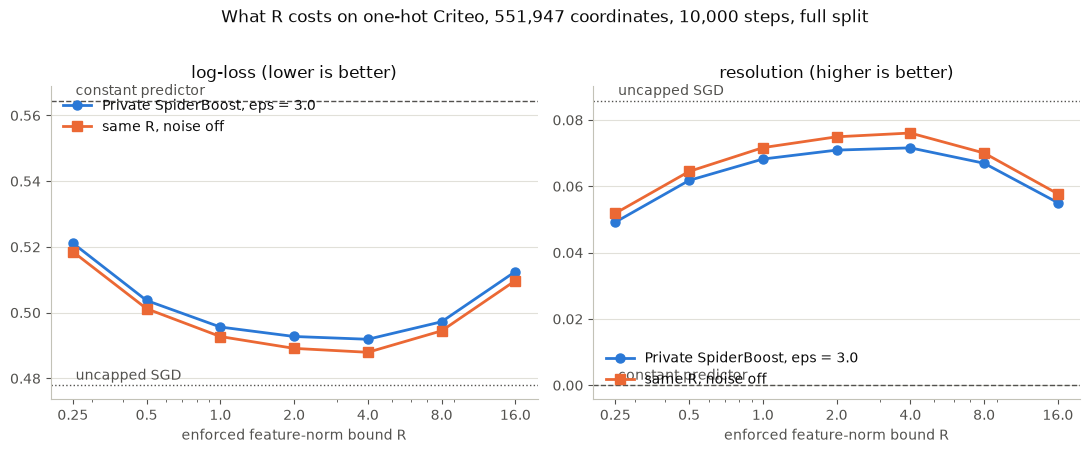

In [9]:
def panels(results, ceiling, constant):
    """Log-loss and resolution against R, both arms, the one chain."""
    axis_values = [result["R"] for result in results]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

    for ax, key, name, corner in (
            (axes[0], "loss", "log-loss (lower is better)", "upper left"),
            (axes[1], "resolution", "resolution (higher is better)",
             "lower left"),
    ):
        ax.axhline(constant[key], color=MUTED, linestyle="--", linewidth=1)
        ax.axhline(ceiling[key], color=MUTED, linestyle=":", linewidth=1)
        ax.plot(axis_values, [r["private"][key] for r in results], marker="o",
                color=PRIVATE_C,
                label=f"Private SpiderBoost, eps = {TARGET_EPSILON}")
        ax.plot(axis_values, [r["control"][key] for r in results], marker="s",
                color=CONTROL_C, label="same R, noise off")
        ax.set_xscale("log")
        ax.set_xticks(axis_values)
        ax.set_xticklabels([str(value) for value in axis_values])
        ax.set_xlabel("enforced feature-norm bound R")
        ax.set_title(name)
        ax.grid(axis="y")
        ax.annotate("constant predictor", (axis_values[0], constant[key]),
                    textcoords="offset points", xytext=(2, 4), color=MUTED)
        ax.annotate("uncapped SGD", (axis_values[0], ceiling[key]),
                    textcoords="offset points", xytext=(2, 4), color=MUTED)
        ax.legend(loc=corner)

    fig.suptitle(f"What R costs on one-hot Criteo, {ONE_HOT_WIDTH:,} "
                 f"coordinates, {STEPS:,} steps, full split", y=1.02)
    fig.tight_layout()
    plt.show()


panels(grid, ceiling, constant)

## What this shows, and what it does not

**The `L0`-Lipschitz assumption is defensible on one-hot Criteo, and the `R`
that makes it true does not drown the signal.** Over a window running from
`R = 0.5` to `R = 8` the private arm keeps most of the uncapped non-private
model's resolution, and that window contains `R = 1`. At `R = 1` and
`eps = 3, delta = 1e-6`, Private SpiderBoost reaches test log-loss `0.4956`
against the constant predictor's `0.5645`, PR-AUC `0.4888` against a floor of
`0.2520`, and `0.0682` of resolution — 79% of the uncapped non-private model's
`0.0858` and 92% of its PR-AUC.

**The optimum is interior and just under a ceiling the encoding fixes.** The
best row is `R = 4.0`, and the largest augmented norm this encoding can produce
is `≈ 5.77`. Those two numbers are close for a reason: a cap below the ceiling
buys a smaller `L0` at the price of rescaling real records, a cap above it buys
nothing at all, and the trade turns over just below where the records stop
being touched. That is a statement about the encoding's geometry, which is
public, and not a fitted quantity.

**This is the same shape the frequency-encoded execution found, at a different
scale.** That one straddled a largest standardized row norm near 16.7 and this
one a ceiling of 5.77; both put a workable window around `R = 1` with cliffs on
either side. What does not transfer is the level — every number here is on
551,947 coordinates and is not comparable row-for-row with a 39-feature run.

Three things this does not settle.

- *Where `R` comes from, when it is not 1.* `R = 4` scores best and is not
  available on the same terms: nothing outside this notebook justifies it, and
  this notebook is a non-private exploratory run whose own epsilon is invalid.
  ADR-0012 puts that obligation on whoever reports the number and gives the
  library no way to record it.
- *One seed, no repeats.* Every row is a single run from a single
  initialization. The flat top spans `0.0034` of resolution across `R = 1, 2, 4`
  and nothing here bounds the run-to-run spread, so the ordering *within* the
  flat top is not resolved and should not be read as one. The cliffs at both
  ends are an order of magnitude larger and are not in doubt.
- *This schedule and this budget.* One phase size, one batch pair, one step
  count, one ε. The `R` that is best at this shape need not be best at another,
  and the SpiderBoost sweep is where the shape itself is swept.

Not shown, and not claimed:

- **There is no standardized arm.** ADR-0020 declines the axis, so ADR-0013's
  price is not paid twice here the way the frequency-encoded execution paid it.
  This notebook is one grid, not two.
- **The preprocessing statistics are unaccounted** (ADR-0008), and on this
  encoding the largest of them is the vocabulary: 551,947 columns whose
  existence and order are a function of the training rows.
- **The operating point is a choice.** Every confusion matrix above thresholds
  at the training base rate; a different threshold gives different precision
  and recall from the same model, while the ranking does not move.
- **The ε is RDP's** (ADR-0011) and is assumed rather than enforced: Algorithm 2
  has no clipping line, so the guarantee holds only if the shipped per-sample
  loss really is `L0`-Lipschitz with the constant its noise was calibrated
  against.